In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import (
    plot_grid,
    plot_with_bands,
    plot_heatmap,
    plot_scatter_markers,
)
import ast
import numpy as np
from functools import partial

In [2]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
}

plt.rcParams.update(rcparams)

In [3]:
linestyles = {"RV": "-", "DC": "--", "QAP": "-.", "CVM1": ":", "CVM2": ":"}

colors = {
    "DC": "#4285F4",  # Blue
    "CVM1": "#EA4335",  # Red
    "CVM2": "#9467bd",  # Purple
    "QAP": "#38761D",  # Dark Green
    "RV": "#FBBC05",  # Yellow
}

marker_map = {"DC": "x", "CVM1": "o", "CVM2": "s", "QAP": "D", "RV": "v"}

plotting_function = partial(plot_with_bands, colors=colors, linestyles=linestyles)

In [4]:
results1 = pd.read_csv("simulation_results_20260408_1942.csv")

In [5]:
# null hp
results2 = pd.read_csv("simulation_results_20260408_1318.csv")

In [6]:
results_concat = pd.concat([results1, results2], ignore_index=True)

In [7]:
import re


def parse_config_string(s):
    # extract rough key-value pairs
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # Looks for 'column_covariance': array([...]) including newlines and spaces
    cov_match = re.search(
        r"'column_covariance':\s*array\(\s*\[(.*?)\s*\]\s*\)", s, re.DOTALL
    )
    if cov_match:
        # Clean up the string representation of the array for easier storage/viewing
        clean_cov = cov_match.group(1).replace("\n", "").replace(" ", "")
        pairs["column_covariance"] = f"[{clean_cov}]"

    # extract method class specifically from the 'method' field
    method_val_match = re.search(r"'method':\s*(.*?)(?=,\s*'[^']+':|$|})", s, re.DOTALL)
    method_class, test_function = None, None

    if method_val_match:
        method_val = method_val_match.group(1)
        cm = re.search(r"<class '([^']+)'>", method_val)
        if cm:
            method_class = cm.group(1).split(".")[-1]
        fm = re.search(r"test_function=<function ([^ ]+)", method_val)
        if fm:
            test_function = fm.group(1)

    if method_class == "PermutationTest" and test_function:
        method = f"{method_class}_{test_function}"
    else:
        method = method_class
    pairs["method"] = method

    # extract solver
    solver_match = re.search(r"'solver':\s*<function ([^ ]+)", s)
    if solver_match:
        pairs["solver"] = solver_match.group(1)

    # clean up np.int64/np.float64 wrappers
    for k, v in pairs.items():
        nm = re.match(r"np\.\w+\(([^)]+)\)", str(v).strip())
        if nm:
            pairs[k] = nm.group(1)

    # extract degree
    pairs["degree"] = (
        re.search(r"degree=(\d+)", s).group(1)
        if re.search(r"degree=(\d+)", s)
        else "NA"
    )

    return pairs

In [8]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)
    try:
        return ast.literal_eval(s_clean)
    except Exception as e:
        return {
            "Rejection": np.nan,
            "FalseRejection": np.nan,
            "FalseAcceptance": np.nan,
            "TrueRejection": np.nan,
            "TrueAcceptance": np.nan,
            "RelativeFrobeniusNorm_x": np.nan,
            "RelativeFrobeniusNorm_z": np.nan,
            "ProcrustesDistance_x": np.nan,
            "ProcrustesDistance_z": np.nan,
        }

In [9]:
results = results_concat.copy()
results["args"] = results["args"].apply(parse_config_string)

In [10]:
results["ComputeAll"] = results["ComputeAll"].apply(parse_result_string)

In [11]:
results["density"] = results["density"].apply(
    lambda x: re.findall(r"np\.float64\((.*?)\)", x)
)
results["density_A"] = results["density"].apply(lambda x: x[0])
results["density_B"] = results["density"].apply(lambda x: x[1])

In [12]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results["n"] = results["args"].apply(lambda x: x.get("n", "NA"))
results["k"] = results["args"].apply(lambda x: x.get("k", "NA"))
results["method"] = results["args"].apply(lambda x: x.get("method", "NA").strip("'"))
results["solver"] = results["args"].apply(lambda x: x.get("solver", "NA").strip("'"))
results["copula"] = results["args"].apply(
    lambda x: x.get("copula_type", "NA").strip("'")
)
results["dgp_name"] = results["args"].apply(
    lambda x: x.get("dgp_name", "NA").strip("'")
)
results["marginals"] = results["args"].apply(
    lambda x: x.get("marginals", "NA").strip("'")
)
results["rho"] = results["args"].apply(
    lambda x: x.get("rho", "NA").replace("np.float64(", "").replace(")", "")
)
results["rho"] = results["rho"].apply(lambda x: float(x))
results["degree"] = results["args"].apply(
    lambda x: x.get("degree", "NA").replace("np.int64(", "").replace(")", "")
)

In [13]:
results["n"] = results["n"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)
results["k"] = results["k"].apply(
    lambda x: int(x.replace("np.int64(", "").replace(")", ""))
)

In [14]:
results_all = results.copy()

In [15]:
results_all["dgp"] = results_all["args"].apply(lambda x: x.get("dgp_name", "NA"))
results_all["dgp_name"] = [x.split("_")[0].strip("'") for x in results_all["dgp"]]
results_all["copula"] = [x.split("_")[1].strip("'") for x in results_all["dgp"]]

In [16]:
results_all["RelativeFrobeniusNorm_x"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results_all["RelativeFrobeniusNorm_z"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)

results_all["ProcrustesDistance_x"] = results_all["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_x", np.nan)
)
results_all["ProcrustesDistance_z"] = results_all["ComputeAll"].apply(
    lambda x: x.get("ProcrustesDistance_z", np.nan)
)

results_all["FalseRejection"] = (
    results_all["ComputeAll"].apply(lambda x: x["FalseRejection"]).astype(bool)
)
results_all["TrueRejection"] = (
    results_all["ComputeAll"].apply(lambda x: x["TrueRejection"]).astype(bool)
)
results_all["Rejection"] = (
    results_all["ComputeAll"].apply(lambda x: x["Rejection"]).astype(bool)
)

In [17]:
results_all["avg_rel_frob_x"] = results_all.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["RelativeFrobeniusNorm_x"].transform("mean")

results_all["avg_proc_dist_x"] = results_all.groupby(
    ["n", "method", "marginals", "copula", "dgp_name"]
)["ProcrustesDistance_x"].transform("mean")

In [18]:
results_all["permutation_type"] = results_all["RelativeFrobeniusNorm_x"].apply(
    lambda x: "observed" if np.isnan(x) else "latent"
)
results_all["method"] = results_all["method"].replace(
    {
        "DiffusionCorrelation": "DC",
        "RVPermutationTest": "RV",
        "ObservedCVM": "CVM",
    }
)
results_all["marginals"] = results_all["marginals"].replace(
    {"chi 5": "chi df=5", "t 5": "t df=5", "uniform -1 1": "unif(-1, 1)"}
)
results_all.rename(columns={"TrueRejection": "Power"}, inplace=True)

In [19]:
temp = results_all[results_all["method"] == "CVM"].copy()
temp["method"] = temp["method"] + temp["degree"].astype(str)
results_all[results_all["method"] == "CVM"] = temp.copy()

In [20]:
results_all = results_all[results_all["edge_var"] == "1"]
# results_all = results_all[~results_all['degree'].isin(['1', '3'])]

In [21]:
def label_covariance(input):
    arr = ast.literal_eval(input["column_covariance"])
    return np.round(max(np.linalg.eigvals(arr)) / min(np.linalg.eigvals(arr)), 2)

In [22]:
results_all["column_covariance"] = results_all["args"].apply(label_covariance)

In [23]:
results_all["FalseRejection"] = results_all["FalseRejection"].astype(float)

### Defining different aggregations

In [24]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [25]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == 0.5)].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == 0.2)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.5)].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.2)].copy()

## Type I error

**Ensure type I error is controlled at 5%**

In [26]:
agg_null_gaussian = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["marginals", "method", "column_covariance", "copula"],
)

agg_null_bernoulli = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="n",
    factors=["marginals", "method", "column_covariance", "copula"],
)

agg_null_gaussian_frob = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula", "column_covariance"],
)
agg_null_bernoulli_frob = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula", "column_covariance"],
)

agg_null_gaussian_proc = aggregate_results(
    results_null_gaussian,
    y_axis="FalseRejection",
    x_axis="avg_proc_dist_x",
    factors=["marginals", "method", "permutation_type"],
)
agg_null_bernoulli_proc = aggregate_results(
    results_null_bernoulli,
    y_axis="FalseRejection",
    x_axis="avg_proc_dist_x",
    factors=["marginals", "method", "permutation_type"],
)

In [27]:
rcparams = {
    "text.usetex": False,  # Disabled LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.weight": "normal",  # Bolds all general text
    "font.size": 17,
    "figure.titlesize": 17,
    "figure.titleweight": "normal",  # Bolds the main figure title
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.labelweight": "normal",  # Bolds axis labels (x, y)
    "axes.titleweight": "normal",  # Bolds axis titles
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}

plt.rcParams.update(rcparams)

In [28]:
agg_null_gaussian["FalseRejection_sem"] = agg_null_gaussian[
    "FalseRejection_sem"
].astype(np.float64)
agg_null_gaussian["FalseRejection_mean"] = agg_null_gaussian[
    "FalseRejection_mean"
].astype(np.float64)

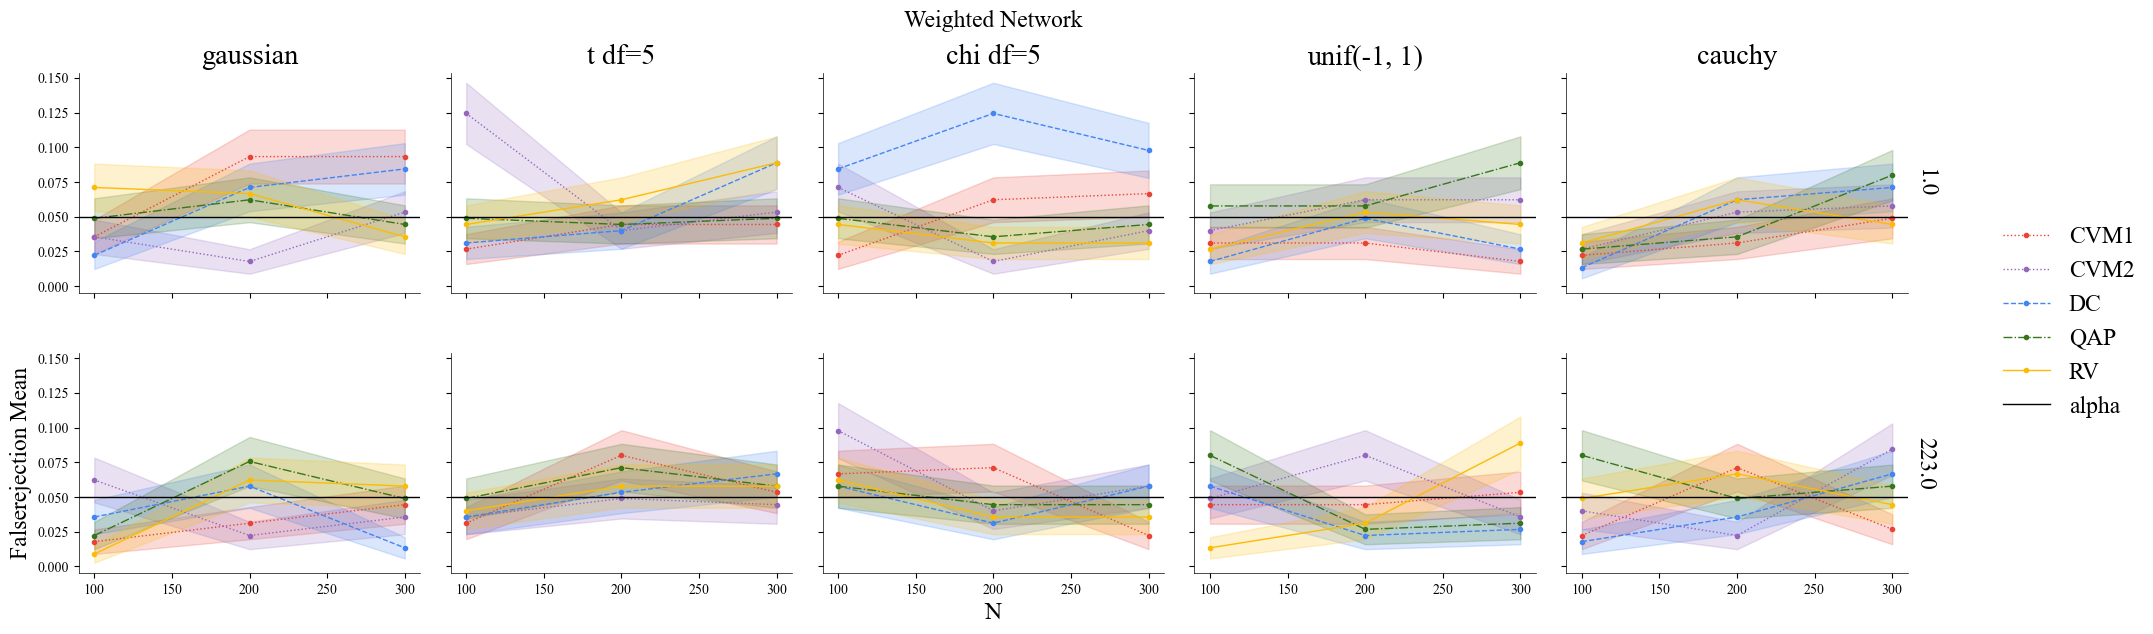

In [29]:
temp = agg_null_gaussian.copy()
temp = agg_null_gaussian[agg_null_gaussian["copula"] == "gaussian"]

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals", "column_covariance"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Weighted Network",
    hline=0.05,
    hline_name="alpha",
    show_col_names=False,
    show_row_names=False,
    col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals", "permutation_type"],
#     height=2,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=True,
#     title="Weighted Network",
#     hline=0.05,
#     hline_name="alpha",
#     show_row_titles=False,
#     show_col_names=False,
#     col_order=['gaussian', 't df=5', 'chi df=5', 'unif(-1, 1)', 'cauchy'],
#     save_path='figures/false_rejection_rate_weighted_network'
# )

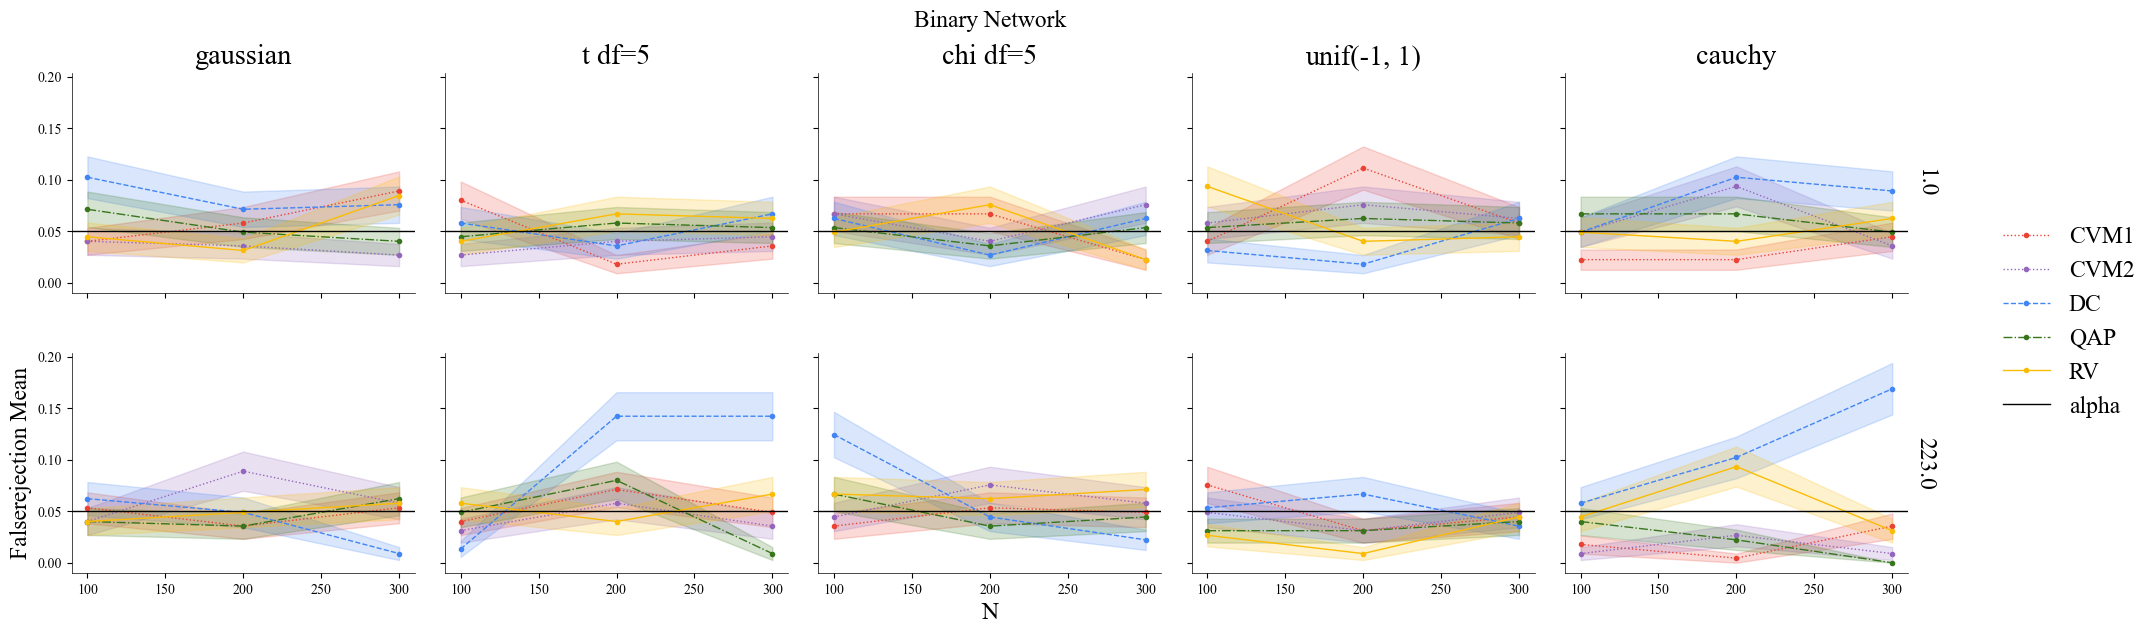

In [30]:
temp = agg_null_bernoulli.copy()
temp = agg_null_bernoulli[agg_null_bernoulli["copula"] == "gaussian"]

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals", "column_covariance"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=True,
    title="Binary Network",
    hline=0.05,
    hline_name="alpha",
    show_row_titles=True,
    show_row_names=False,
    show_col_names=False,
    col_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

flipping


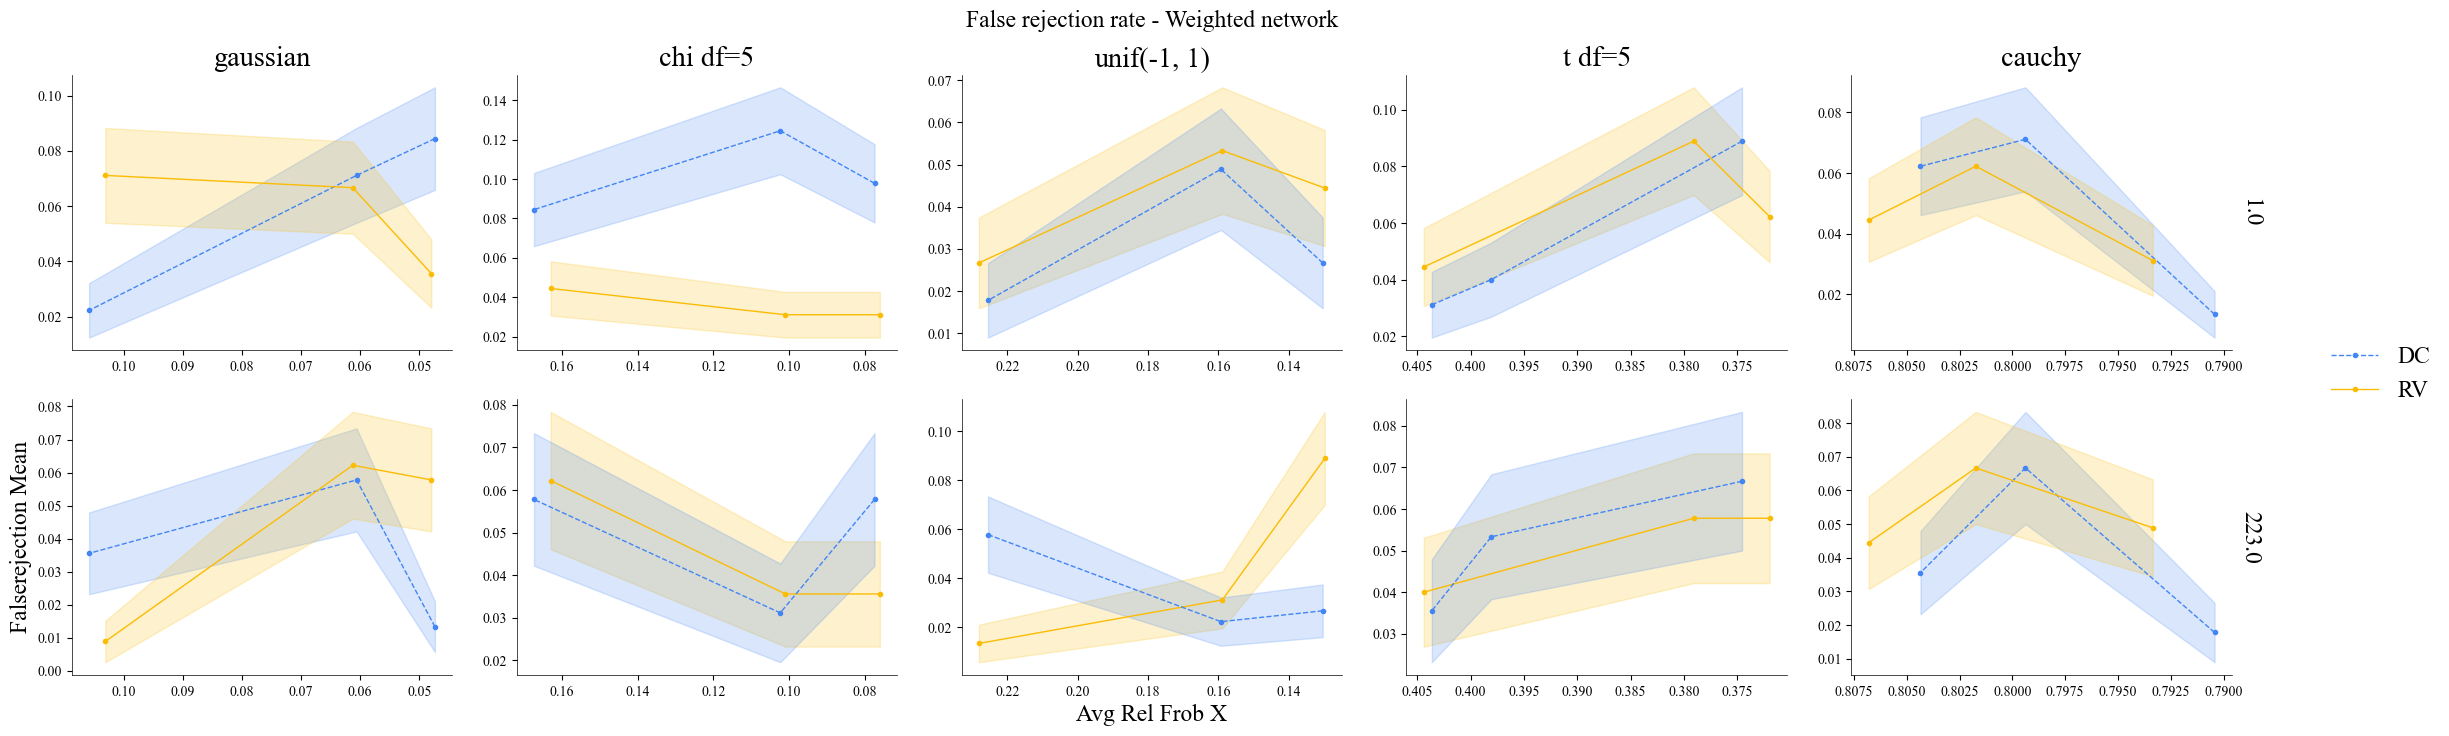

In [31]:
temp = agg_null_gaussian_frob.copy()
temp = agg_null_gaussian_frob[agg_null_gaussian_frob["copula"] == "gaussian"]

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="FalseRejection_mean",
    factors=["method", "marginals", "column_covariance"],
    height=3.5,
    se_bands="FalseRejection_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
    show_row_names=False,
    show_col_names=False,
)

In [32]:
# temp = agg_null_gaussian_proc.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="avg_proc_dist_x",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals",],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=False,
#     share_y=False,
#     title="False rejection rate - Weighted network",
#     flip_x_axis=True,
# )

In [33]:
# temp = agg_null_bernoulli_frob.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="avg_rel_frob_x",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals","column_covariance"],
#     height=3.5,
#     se_bands="FalseRejection_sem",
#     share_x=False,
#     share_y=False,
#     title="False rejection rate - Binary network",
#     flip_x_axis=True,
#     show_row_names=False,
#     show_col_names=False
# )

In [34]:
# temp = agg_null_bernoulli_proc.copy()

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="avg_proc_dist_x",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals",],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=False,
#     share_y=False,
#     title="False rejection rate - Binary network",
#     flip_x_axis=True,
# )

### Power

In [35]:
agg_alt_02_gaussian = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "method", "copula", "column_covariance"],
)
agg_alt_02_bernoulli = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "method", "copula", "column_covariance"],
)

agg_alt_02_gaussian_frob = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula", "column_covariance"],
)

agg_alt_02_bernoulli_frob = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "method", "copula", "column_covariance"],
)

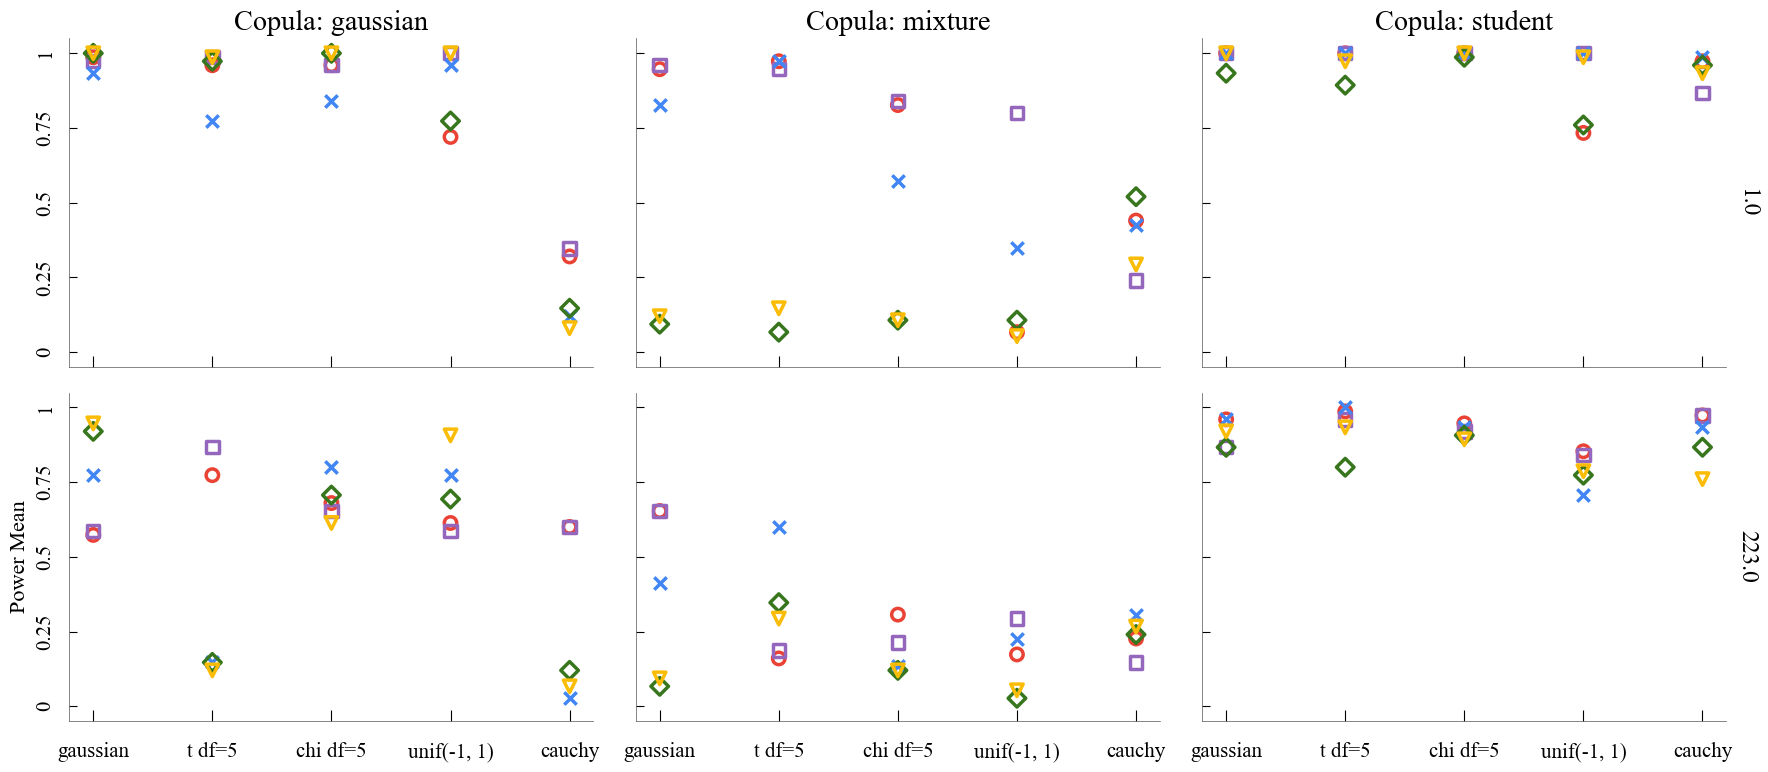

In [36]:
temp = agg_alt_02_gaussian.copy()
temp = temp[temp["n"] == 300]
# temp['copula_variance'] = temp['copula'] + '_' + str(temp['column_covariance'])
# temp = temp[~temp['marginals'].isin(['gaussian', 'uniform -1 1'])]

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula", "column_covariance"],
    height=4,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=False,
    show_row_names=False,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)


plot_grid(
    grouped_stats=temp,
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula", "column_covariance"],
    height=3,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=False,
    show_row_names=False,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
    save_path="figures/power_diff_variance",
)

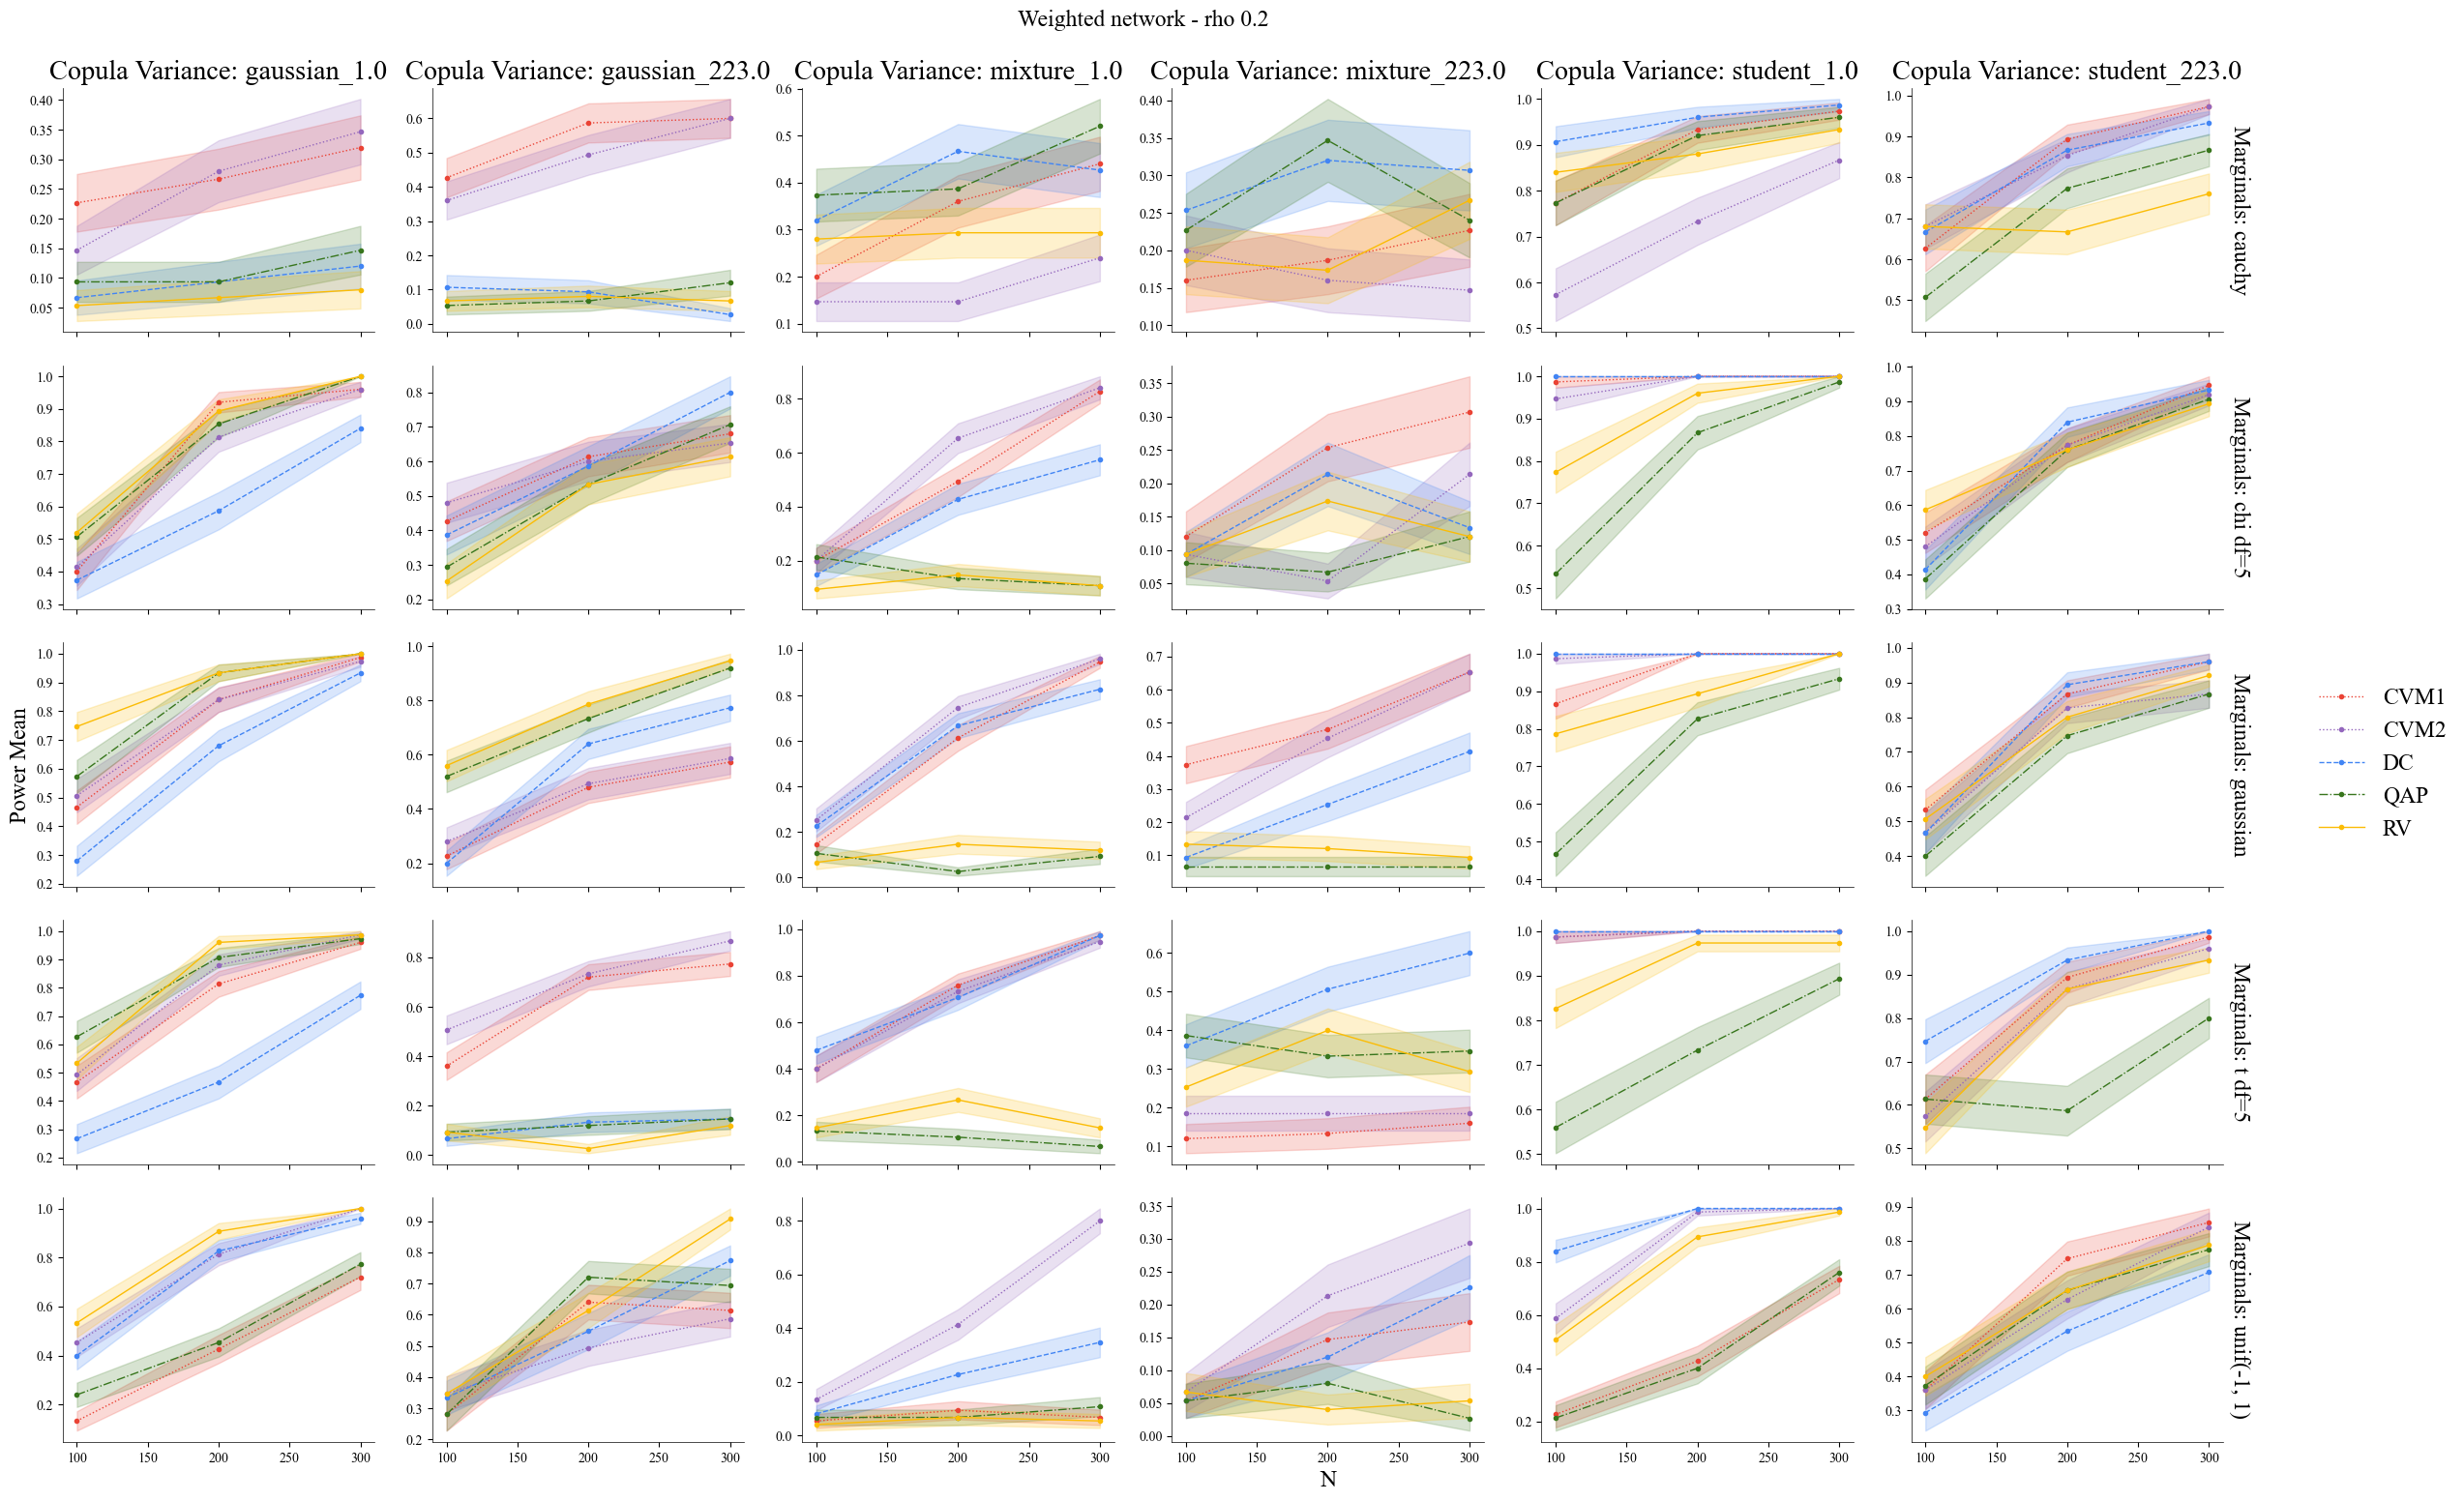

In [37]:
temp = agg_alt_02_gaussian.copy()
temp["copula_variance"] = temp["copula"] + "_" + temp["column_covariance"].astype(str)

plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="n",
    y_axis="Power_mean",
    factors=["method", "copula_variance", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
)

flipping


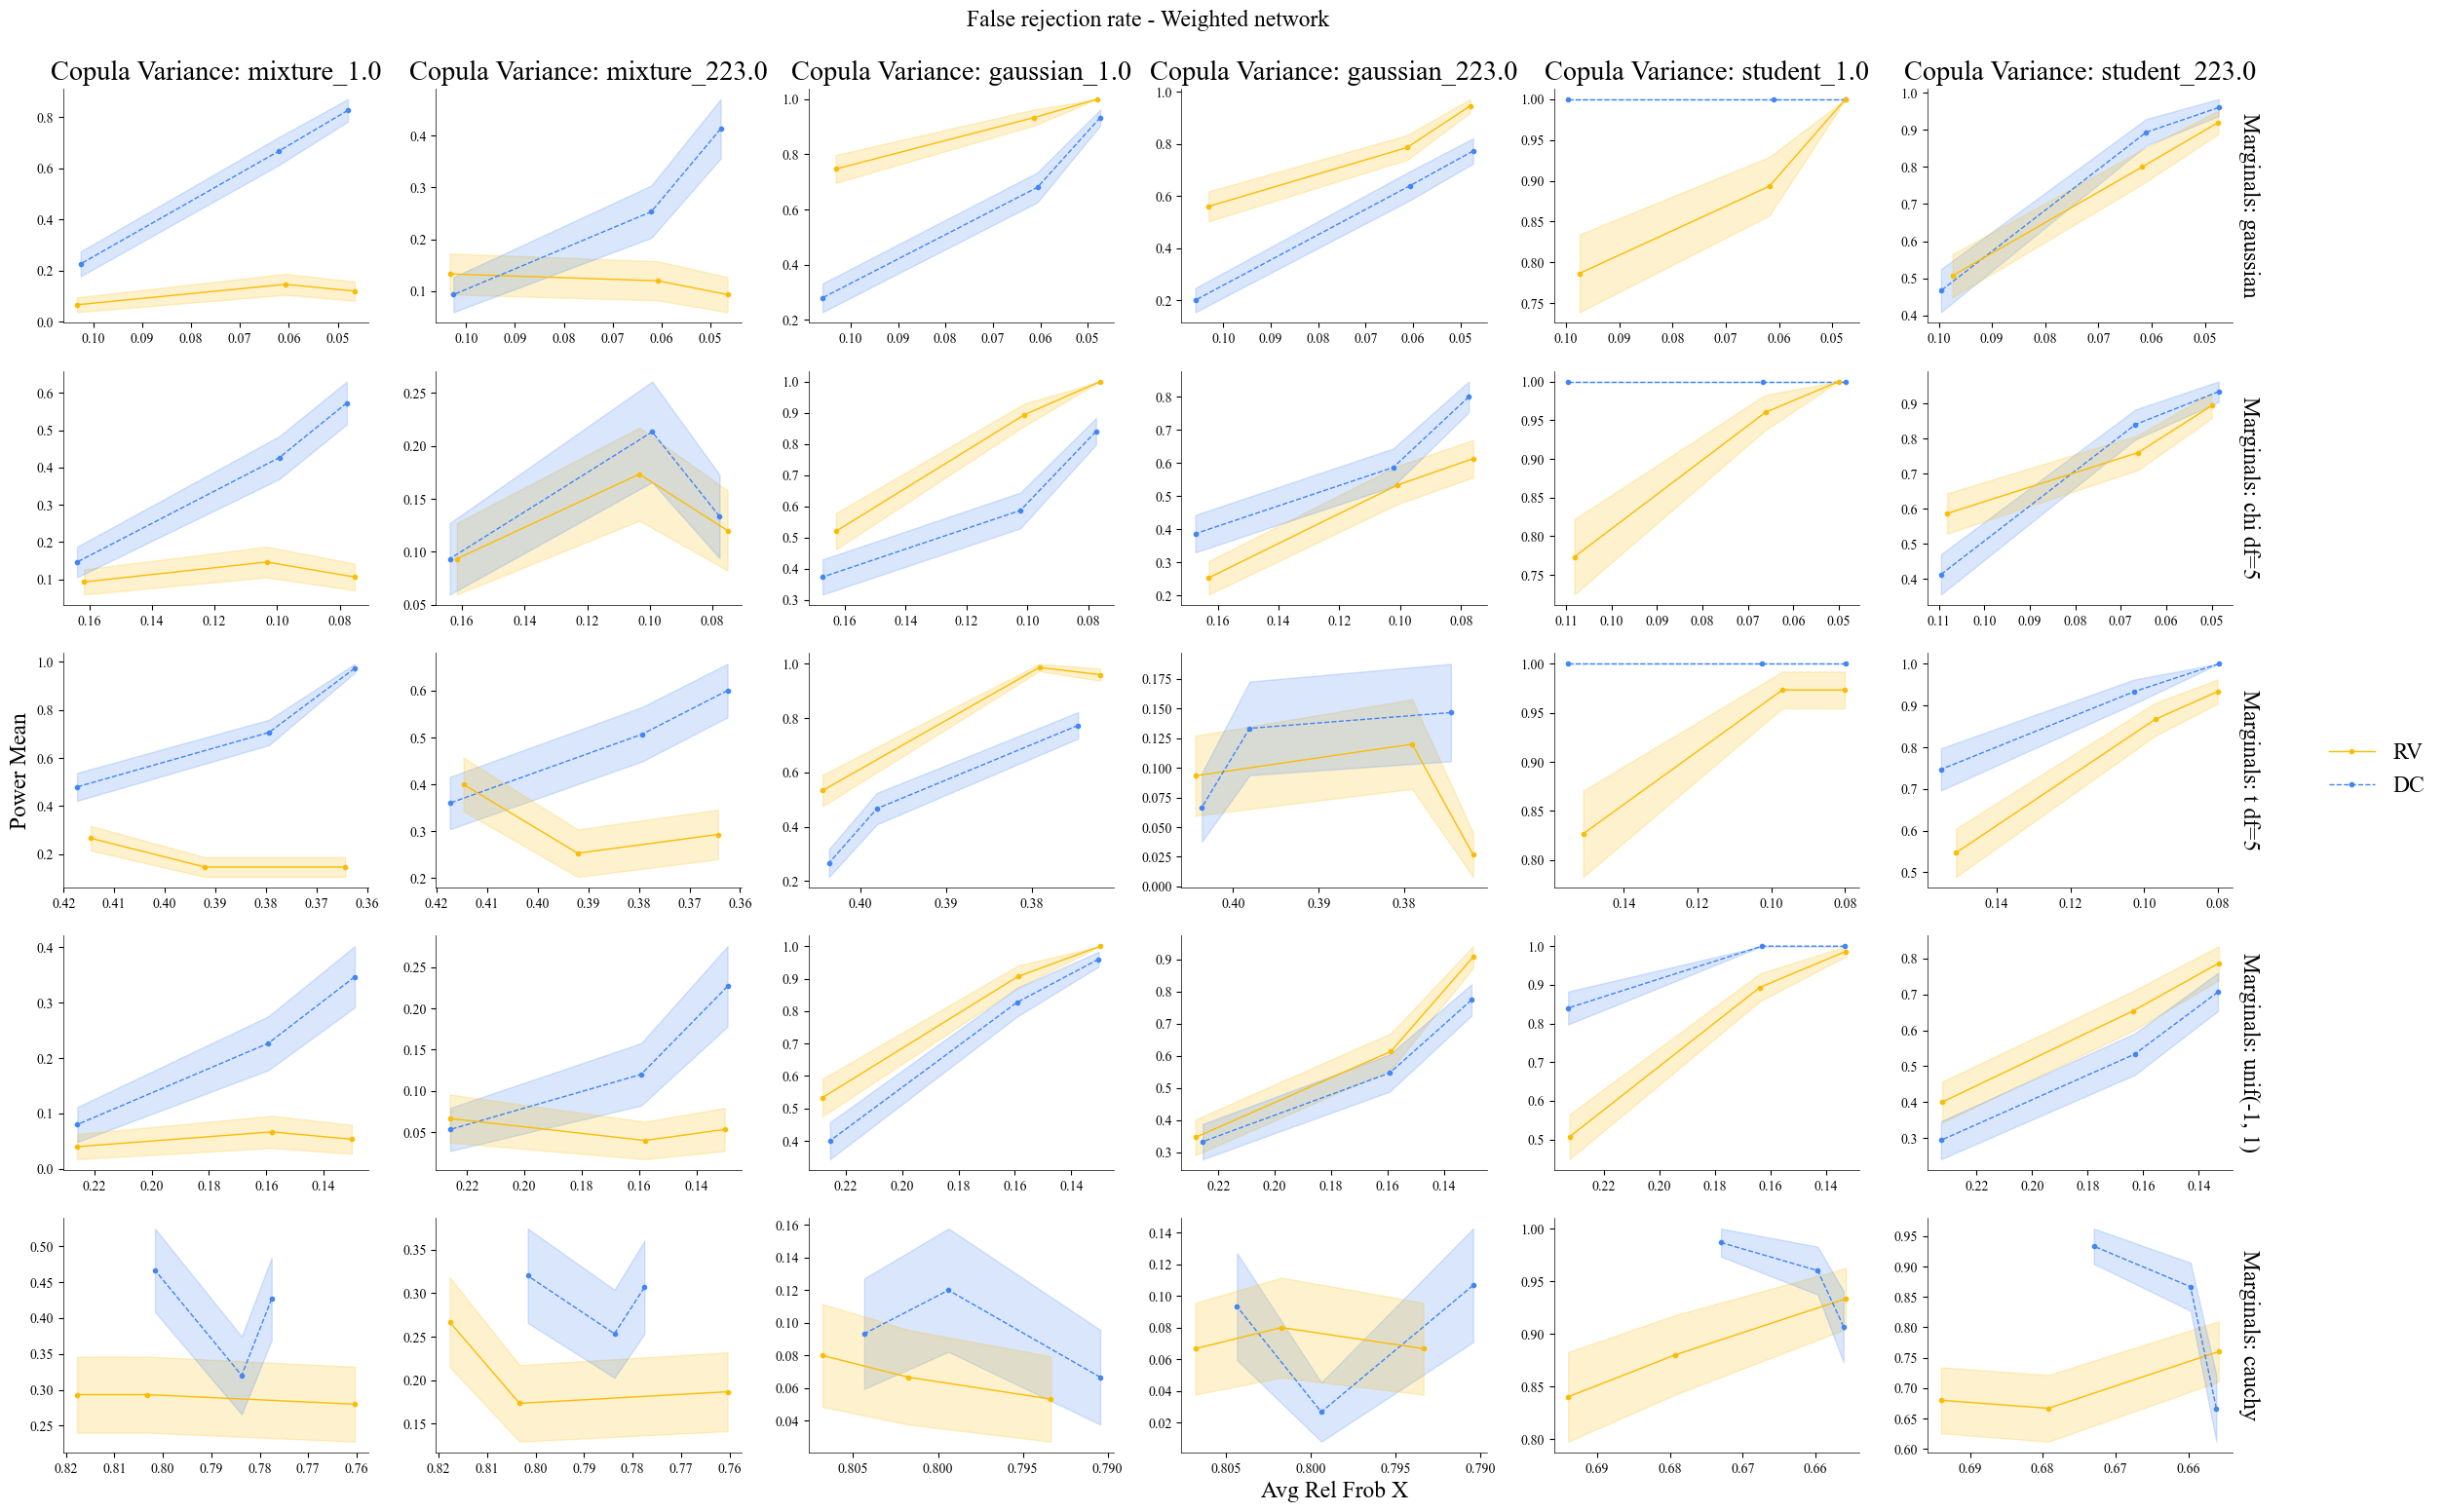

In [38]:
temp = agg_alt_02_gaussian_frob.copy()
temp["copula_variance"] = temp["copula"] + "_" + temp["column_covariance"].astype(str)


plot_grid(
    grouped_stats=temp,
    plotting_function=plotting_function,
    x_axis="avg_rel_frob_x",
    y_axis="Power_mean",
    factors=["method", "copula_variance", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=False,
    share_y=False,
    title="False rejection rate - Weighted network",
    flip_x_axis=True,
)

### Binary network

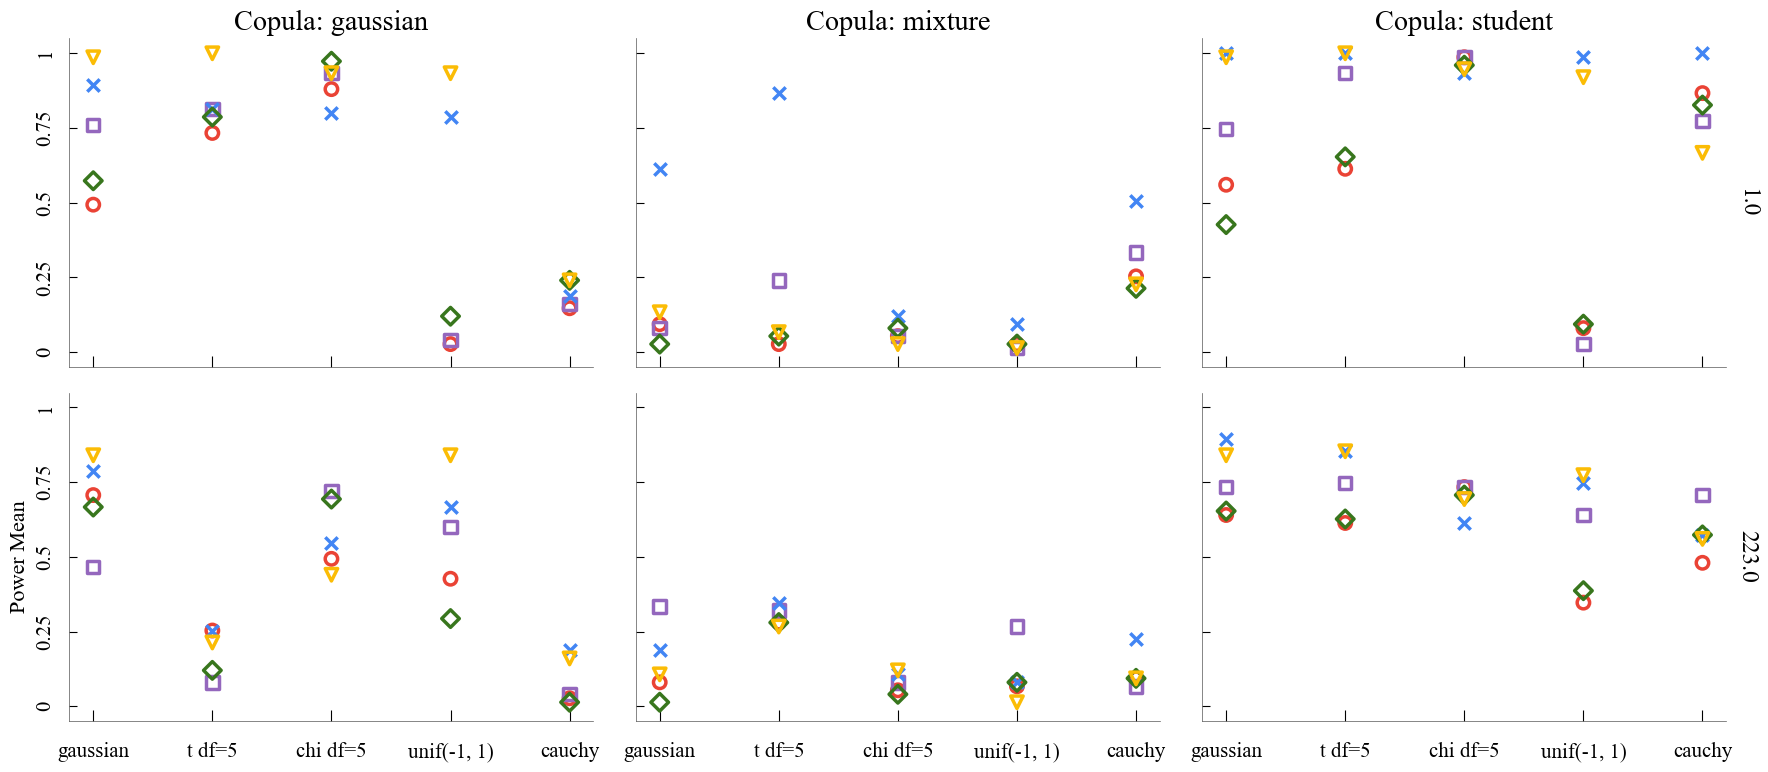

In [39]:
temp = agg_alt_02_bernoulli.copy()
temp = temp[temp["n"] == 300]

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_scatter_markers,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula", "column_covariance"],
    height=4,
    aspect=1.5,
    colors=colors,
    markers=marker_map,
    add_legend=False,
    show_row_names=False,
    title="",
    show_x_axis_title=False,
    x_tick_labelsize=15,  # ← overrides xtick.labelsize: 10 from rcParams
    y_tick_labelsize=15,  # ← same for y (optional)
    x_tick_rotation=0,
    x_order=["gaussian", "t df=5", "chi df=5", "unif(-1, 1)", "cauchy"],
)

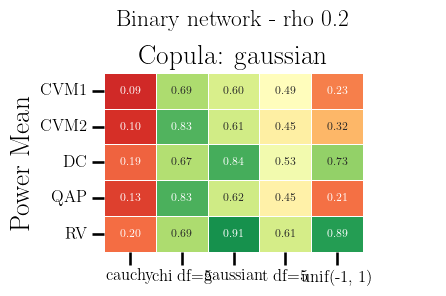

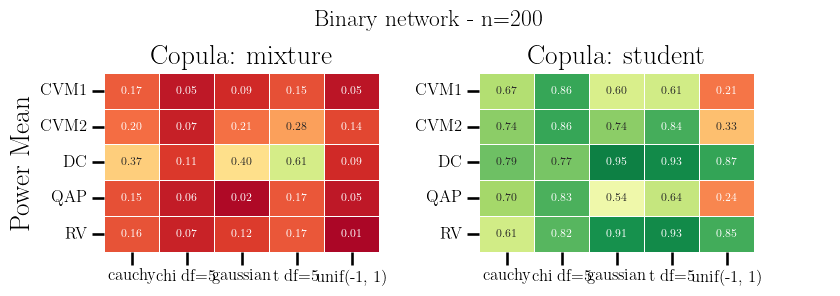

In [40]:
# small tail
import seaborn as sns

sns.set_context("talk", font_scale=1.1)

custom_params = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
}
plt.rcParams.update(custom_params)

temp = agg_alt_02_bernoulli.copy()
temp = temp[~temp["copula"].isin(["gumbel"])]
temp = temp[temp["n"] == 300]
temp.iloc[:, temp.columns.get_loc("method")] = temp["method"].replace(
    {"DistanceCorrelation": "DC", "ObservedCVM": "CVM", "RVPermutationTest": "RV"}
)

plot_grid(
    grouped_stats=temp[temp["copula"].isin(["clayton", "gaussian"])],
    plotting_function=plot_heatmap,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
    name_conversion={"n": "n (Number of nodes)", "marginals": ""},
    show_row_names=False,
)

plot_grid(
    grouped_stats=temp[~temp["copula"].isin(["clayton", "gaussian"])],
    plotting_function=plot_heatmap,
    x_axis="marginals",
    y_axis="Power_mean",
    factors=["method", "copula"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - n=200",
    name_conversion={"n": "n (Number of nodes)", "marginals": ""},
    show_row_names=False,
)